# Hill climbing

## 1. Introduction

[Hill climbing](https://pubsonline.informs.org/doi/10.1287/opre.21.2.498) is a fundamental optimization algorithm that iteratively improves a solution by making small changes and keeping those that lead to better objective values. The name comes from the metaphor of climbing a hill: at each step, you move upward (toward better solutions) until you reach a peak.

The basic algorithm works as follows:

1. **Start with an initial solution**: Begin with a random or heuristically-generated starting point
2. **Generate a neighbor**: Create a new candidate solution by making a small change to the current solution
3. **Evaluate**: Calculate the objective function value for the new candidate
4. **Accept or reject**: If the new solution is better, accept it as the current solution; otherwise, reject it
5. **Repeat**: Continue steps 2-4 until a stopping criterion is met (e.g., maximum iterations, no improvement for N steps)

Hill climbing is an example of an 'anytime' algorithm - i.e. it can be stopped at any point and still provide a valid solution. This allows the user a great deal of control over the computational budget.
Pure hill climbing is a **greedy** algorithm, it only accepts improvements and never worse solutions. This makes it simple and efficient, but it has a critical limitation: it can get stuck in local optima (solutions that are not truly the best overall solution, just 'good'/better than the starting point).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Visualizing the optimization landscape

Let's visualize a simple 1D optimization problem to understand how hill climbing works. We'll create a function with multiple peaks (local optima) and one global optimum.

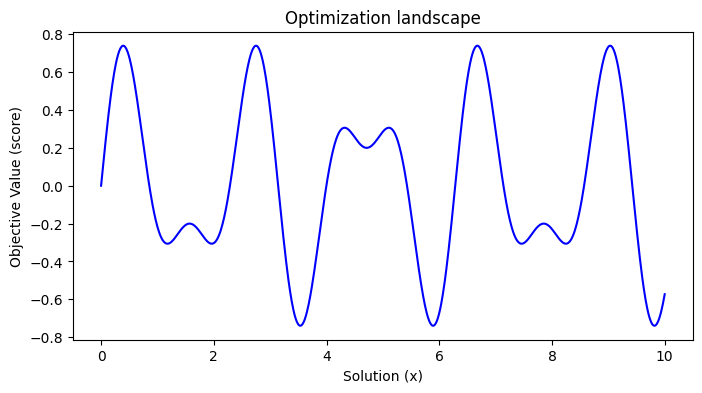

In [85]:
# Define a simple objective function with multiple local optima
def objective_function(x):
    """A multimodal function with several peaks."""

    return 0.5 * np.sin(3 * x) + 0.3 * np.sin(5 * x)

# Create the landscape
x = np.linspace(0, 10, 1000)
y = objective_function(x)

plt.figure(figsize=(8, 4))
plt.title('Optimization landscape')
plt.plot(x, y, 'b-', label='Objective Function')
plt.xlabel('Solution (x)')
plt.ylabel('Objective Value (score)')
plt.show()

## 3. Simple hill climbing implementation

Let's implement a basic hill climbing algorithm to optimize the function above.

In [86]:
def simple_hill_climber(objective_func, x_min, x_max, max_iterations=100, step_size=0.5):
    """Simple hill climbing optimizer for 1D problems.
    
    Args:
        objective_func: Function to maximize
        x_min: Minimum value for x
        x_max: Maximum value for x
        max_iterations: Maximum number of iterations
        step_size: Size of perturbations to try
        
    Returns:
        best_x: Best solution found
        best_score: Best objective value found
        history: List of (x, score) tuples for each iteration
    """

    # Initialize solution
    current_x = np.random.uniform(x_min, x_max)
    current_score = objective_func(current_x)
    
    best_x = current_x
    best_score = current_score
    
    history = [(current_x, current_score)]
    
    for _ in range(max_iterations):

        # Generate a neighbor by adding random noise
        neighbor_x = current_x + np.random.uniform(-step_size, step_size)
        
        # Keep within bounds
        neighbor_x = np.clip(neighbor_x, x_min, x_max)
        
        # Evaluate the neighbor
        neighbor_score = objective_func(neighbor_x)
        
        # Accept if better (greedy)
        if neighbor_score > current_score:
            current_x = neighbor_x
            current_score = neighbor_score
            
            # Update best if this is the best so far
            if current_score > best_score:
                best_x = current_x
                best_score = current_score
        
        history.append((current_x, current_score))
    
    return best_x, best_score, history

## 4. Optimization run

Let's run the hill climber multiple times from different starting points to see how it behaves.

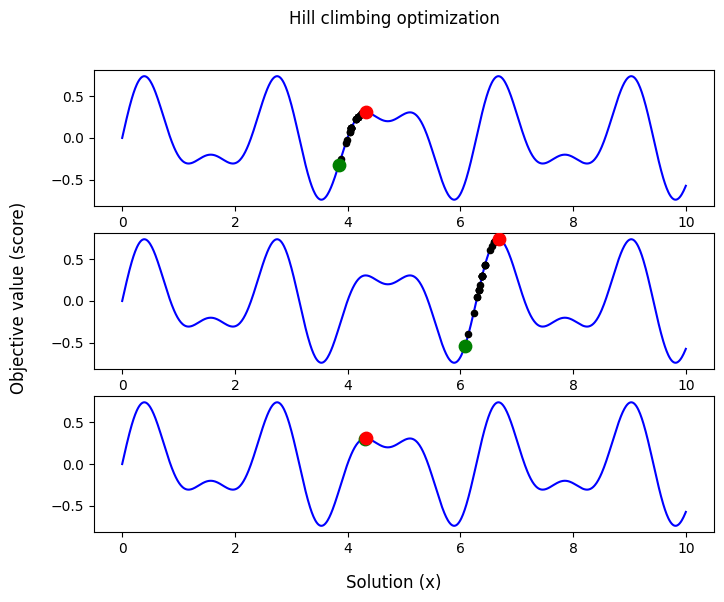

In [87]:
fig, axs = plt.subplots(3, 1, figsize=(8, 6))
axs = axs.flatten()

fig.suptitle('Hill climbing optimization')
fig.supxlabel('Solution (x)')
fig.supylabel('Objective value (score)')

for i in range(3):

    # Run the optimization
    best_x, best_score, history = simple_hill_climber(
        objective_function, 
        x_min=0, 
        x_max=10, 
        max_iterations=50,
        step_size=0.1
    )

    # Extract history
    x_hist = [h[0] for h in history]
    y_hist = [h[1] for h in history]

    # Plot the optimization landscape
    axs[i].plot(x, y, 'b-')

    # Plot the steps
    axs[i].scatter(x_hist, y_hist, c='black', s=20, zorder=10, label=f'Steps')

    # Mark starting and ending points
    axs[i].scatter(x_hist[0], y_hist[0], color='green', s=80, zorder=10, label='Start')
    axs[i].scatter(best_x, best_score, color='red', s=80, zorder=10, label='Start')

plt.show()

### Key observations:

1. **Starting point matters**: Different starting positions lead to different final solutions
2. **Local optima**: The algorithm gets stuck at the nearest peak and cannot escape
3. **Greedy behavior**: Once stuck at a local peak, the algorithm stops improving because all neighbors have lower values
4. **No global guarantee**: Pure hill climbing cannot guarantee finding the global optimum

This demonstrates the fundamental limitation of basic hill climbing: **the solution depends heavily on the initial starting point and the algorithm can get trapped in local optima**.

## 5. Convergence behavior

Let's examine how the objective value improves over iterations.

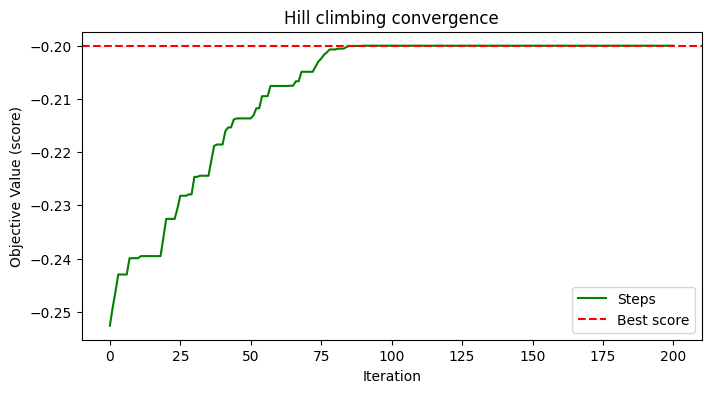

In [99]:
# Run a single instance and plot convergence
best_x, best_score, history = simple_hill_climber(
    objective_function,
    x_min=0,
    x_max=10,
    max_iterations=200,
    step_size=0.01
)

iterations = list(range(len(history)))
scores = [h[1] for h in history]

plt.figure(figsize=(8, 4))
plt.title('Hill climbing convergence')
plt.plot(iterations, scores, 'g-', label='Steps')
plt.axhline(y=best_score, color='r', linestyle='--', label=f'Best score')
plt.xlabel('Iteration')
plt.ylabel('Objective Value (score)')
plt.legend()
plt.show()

Notice how the objective value increases rapidly at first, then plateaus when the algorithm reaches a local optimum. Once at a peak, all neighboring solutions are worse, so no further improvements are accepted.

## 6. Implementation

The `HillClimber` class in this project implements hill climbing with several enhancements:
1. **Simulated annealing** (see notebook 02-simulated_annealing.ipynb) helps escape local optima by accepting stochastically accepting worse solutions 
2. Replica exchange (see notebook 03-replica_exchange.ipynb) runs multiple replicas optimizations with different annealing parameters in parallel and swaps them periodically to further assist the algorithm in finding global solutions
3. **Multi-dimensional optimization**: Works with parameter vectors of any dimension (rather than just one as in this simple example)
4. **Three optimization modes**: 
   - `maximize`: Find highest objective value
   - `minimize`: Find lowest objective value  
   - `target`: Get as close as possible to a target value
5. **Perturbation strategy**: Steps are drawn from a normal distribution centered on zero with a standard deviation calculated as a user specified fraction of the data's range
6. **Convergence detection**: Automatically stops when no improvement is found for N iterations
7. **Checkpointing**: Can save and resume optimization progress